### Gráficos estacionales

Es un gráfico que horizontalmente representa un periodo de tiempo (meses, años, días) en lugar de instantes de tiempo y en el eje vertical se grafican múltiples periodos de tiempo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [2]:
co2 = pd.read_csv('datos/co2.csv',
                parse_dates=['fecha'],
                index_col='fecha')
co2

,co2
fecha,
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4
...,...
2001-12-01,370.3
2001-12-08,370.8
2001-12-15,371.2


<Axes: xlabel='fecha'>

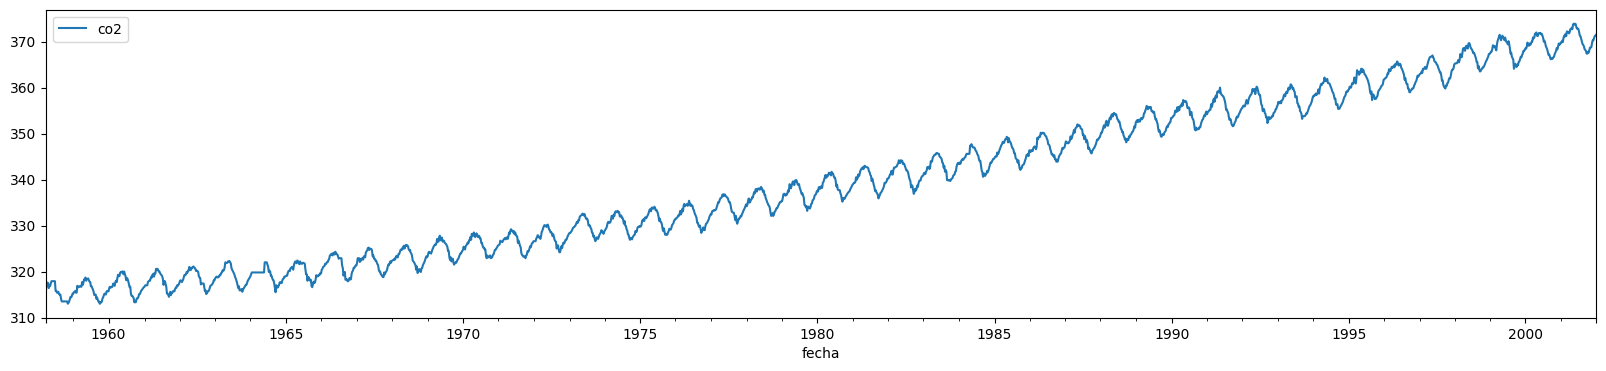

In [3]:
co2.plot(figsize=(20,4))

In [4]:
co2.index # Muestreos semanales

DatetimeIndex(['1958-03-29', '1958-04-05', '1958-04-12', '1958-04-19',
               '1958-04-26', '1958-05-03', '1958-05-10', '1958-05-17',
               '1958-05-24', '1958-05-31',
               ...
               '2001-10-27', '2001-11-03', '2001-11-10', '2001-11-17',
               '2001-11-24', '2001-12-01', '2001-12-08', '2001-12-15',
               '2001-12-22', '2001-12-29'],
              dtype='datetime64[us]', name='fecha', length=2284, freq=None)

In [5]:
co2_M = co2.resample('ME').sum()

In [6]:
co2_M['Mes'] = co2_M.index.month
co2_M['Año'] = co2_M.index.year

co2_M

,co2,Mes,Año
fecha,,,
1958-03-31,316.1,3,1958
1958-04-30,1268.8,4,1958
1958-05-31,1587.1,5,1958
1958-06-30,1271.6,6,1958
1958-07-31,1262.5,7,1958
...,...,...,...
2001-08-31,1477.7,8,2001
2001-09-30,1839.4,9,2001
2001-10-31,1472.2,10,2001


In [7]:
co2_M_pivote = co2_M.pivot(index='Mes', columns='Año', values='co2')
co2_M_pivote

Año,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,...,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001
Mes,,,,,,,,,,,,,,,,,,,,,
1,NaN,1577.5,1581.9,1267.7,1271.7,1274.9,1278.0,1597.0,1602.7,1290.6,...,1423.6,1783.4,1791.6,1439.9,1448.1,1452.5,1826.7,1840.6,1845.1,1480.7
2,NaN,1265.5,1267.9,1270.6,1274.5,1275.8,1599.0,1281.8,1286.3,1289.7,...,1783.4,1428.7,1435.6,1443.7,1452.7,1455.5,1464.8,1475.4,1477.5,1485.3
3,316.1,1267.0,1270.3,1274.1,1598.4,1599.3,1279.2,1283.7,1289.5,1292.0,...,1431.6,1433.7,1439.7,1446.3,1820.3,1822.8,1469.5,1478.4,1481.6,1860.3
4,1268.8,1270.7,1595.6,1597.1,1282.2,1285.1,1279.2,1288.0,1618.3,1621.4,...,1436.3,1437.3,1806.1,1816.8,1458.8,1465.3,1474.1,1483.9,1857.7,1491.1
5,1587.1,1591.7,1279.7,1281.9,1283.6,1288.2,1601.2,1610.3,1296.1,1299.8,...,1797.7,1800.9,1446.6,1454.8,1461.3,1833.4,1845.7,1854.2,1486.6,1495.2
6,1271.6,1272.1,1277.8,1279.0,1602.5,1607.3,1287.5,1287.1,1294.8,1296.3,...,1436.5,1438.0,1443.6,1453.0,1824.4,1461.9,1475.0,1481.0,1486.5,1865.3
7,1262.5,1266.1,1590.3,1591.6,1277.7,1278.4,1281.2,1605.2,1614.4,1612.4,...,1428.0,1787.1,1797.3,1809.0,1453.9,1457.5,1470.4,1845.0,1849.7,1485.2
8,1574.8,1574.5,1263.1,1267.1,1270.6,1588.0,1593.1,1274.9,1280.8,1283.4,...,1774.3,1421.3,1429.5,1437.5,1806.6,1812.3,1828.6,1466.8,1471.8,1477.7
9,1254.0,1255.3,1256.7,1575.2,1583.0,1264.6,1266.4,1271.3,1274.8,1596.5,...,1412.1,1415.1,1423.7,1790.0,1437.6,1440.6,1455.7,1458.7,1832.7,1839.4


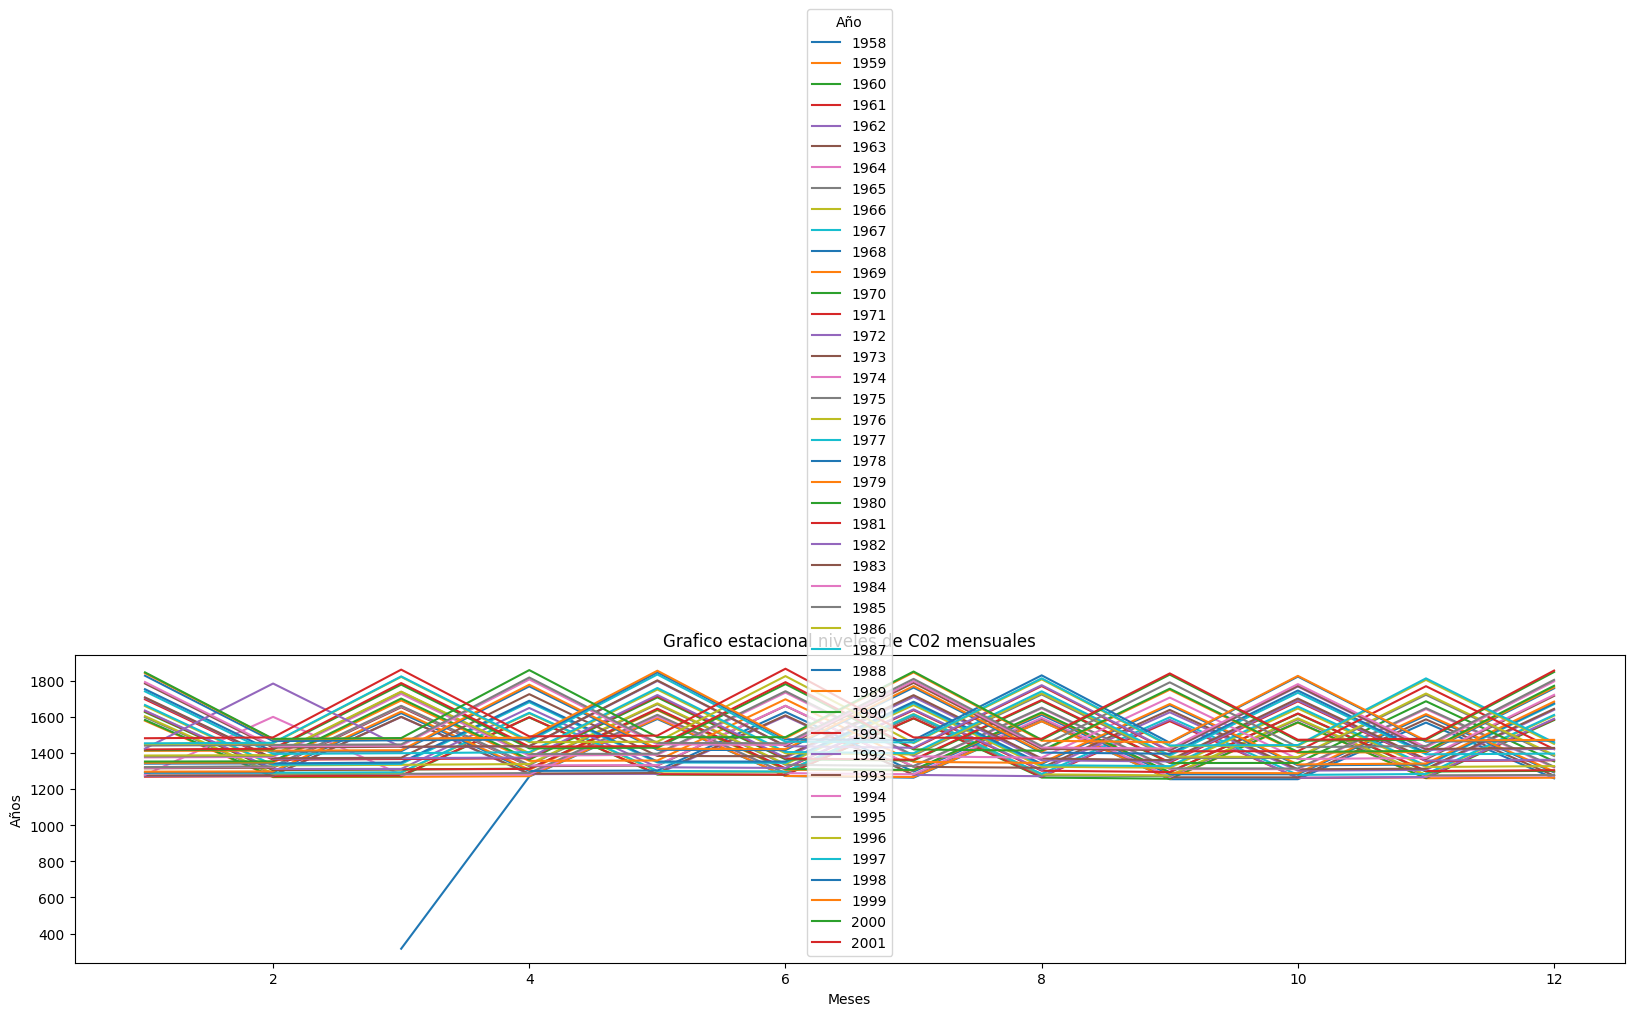

In [8]:
co2_M_pivote.plot(figsize=(20,4))
plt.title('Grafico estacional niveles de C02 mensuales')
plt.xlabel('Meses')
plt.ylabel('Años')
plt.legend(title = 'Año')
plt.show()

# No solamente se aprecia la estacionalidad, también se encuentra la tendencia

In [9]:
co2_STL = STL(co2['co2'], 
            seasonal = 53).fit()

co2_STL_seasonal = co2_STL.seasonal.to_frame('co2')
co2_STL_seasonal
# Este es el componenete estacional con una frecuencia semanal

,co2
fecha,
1958-03-29,1.182860
1958-04-05,1.830737
1958-04-12,1.969616
1958-04-19,2.172439
1958-04-26,2.307398
...,...
2001-12-01,-1.299605
2001-12-08,-0.924924
2001-12-15,-0.655229


In [10]:
co2_STL_seasonal_M = co2_STL_seasonal.resample('ME').sum()

co2_STL_seasonal_M['Mes'] = co2_STL_seasonal_M.index.month
co2_STL_seasonal_M['Año'] = co2_STL_seasonal_M.index.year

co2_STL_seasonal_M_p = co2_STL_seasonal_M.pivot(index = 'Mes', columns = 'Año', values = 'co2')
co2_STL_seasonal_M_p

Año,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,...,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001
Mes,,,,,,,,,,,,,,,,,,,,,
1,NaN,-0.043210,-0.228538,0.059037,-0.086379,-0.231939,-0.377531,-0.414868,-0.577618,-0.249653,...,0.125720,0.400323,0.294775,0.438546,0.357245,0.276388,0.624033,0.533369,0.443554,0.540600
2,NaN,2.327834,2.242673,2.157228,2.071519,1.985586,2.667653,2.454854,2.367553,2.280158,...,3.797382,3.348020,3.279524,3.211505,3.144016,3.077094,3.728293,3.639374,3.550558,3.461840
3,1.182860,4.423838,4.342411,4.260983,5.897822,5.788553,4.911257,4.820733,4.730434,4.640391,...,6.668332,6.538794,6.408183,6.276510,8.451317,8.304417,7.010841,6.895667,6.779544,9.025574
4,8.280190,8.196639,10.416086,10.321104,8.506930,8.437927,8.367803,8.296511,10.779584,10.697387,...,10.603843,10.575829,13.596216,13.568578,11.231964,11.214466,11.195388,11.174686,14.119079,11.733741
5,12.583140,12.588463,10.289376,10.303284,10.316624,10.329259,13.070634,13.091077,10.554909,10.581884,...,15.052028,15.168684,12.234338,12.345068,12.453938,15.450985,15.600471,15.747221,12.924363,13.063615
6,9.228475,9.334155,9.439834,9.545467,11.120048,11.290789,8.731592,8.891899,9.051751,9.211038,...,8.906752,9.124481,9.341862,9.558779,11.413083,8.807189,9.045866,9.284061,9.521744,11.301452
7,3.287569,3.551228,4.002982,4.326796,3.180845,3.437939,3.694611,3.919140,4.241671,4.564004,...,2.918551,2.820398,3.170205,3.520242,2.232674,2.514835,2.797486,2.565873,2.914675,1.721382
8,-4.696955,-4.362077,-4.216052,-3.942802,-3.669535,-5.248516,-4.910367,-4.540506,-4.269103,-3.998019,...,-7.233689,-6.571468,-6.356285,-6.140218,-8.674757,-8.425637,-8.174946,-7.407860,-7.219066,-7.028671
9,-10.622890,-10.412296,-10.200770,-12.951647,-12.723711,-10.642426,-10.477320,-10.311321,-10.144526,-13.120095,...,-13.216023,-13.219241,-13.220739,-16.945423,-14.231525,-14.298090,-14.362934,-14.426006,-18.333411,-18.437633


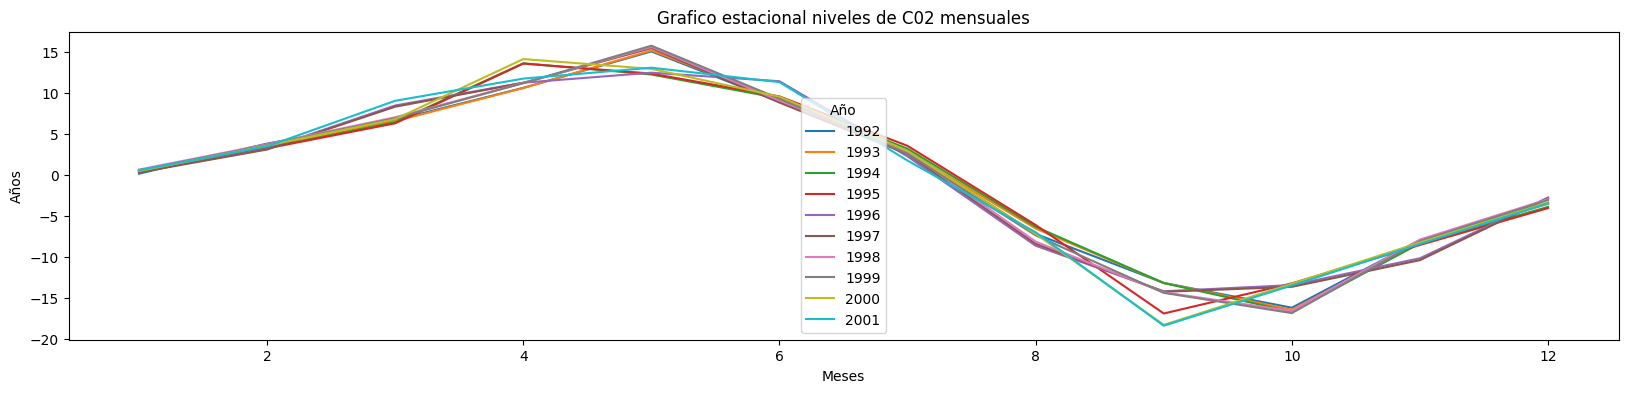

In [11]:
co2_STL_seasonal_M_p.iloc[:,-10:].plot(figsize=(20,4))
plt.title('Grafico estacional niveles de C02 mensuales')
plt.xlabel('Meses')
plt.ylabel('Años')
plt.legend(title = 'Año')
plt.show()